In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider


def ensure_vectorized(func):
    try:
        test = func(np.array([0.0, 1.0]))
        if isinstance(test, np.ndarray) and test.shape == (2,):
            return func
    except Exception:
        pass
    return np.vectorize(func, otypes=[float])


def detect_support(func, search_range=(-50, 50), n_search=20000, tol=1e-6):
    x = np.linspace(search_range[0], search_range[1], n_search)
    y = np.abs(func(x))
    nonzero = np.where(y > tol)[0]
    if len(nonzero) == 0:
        raise ValueError("Function appears to be zero everywhere in search_range; "
                          "widen search_range or check the function.")
    a = x[nonzero[0]]
    b = x[nonzero[-1]]
    pad = (b - a) * 0.02 + 1e-3
    return a - pad, b + pad


def build_visualizer(f, h, n_samples=2000, search_range=(-50, 50)):
    f = ensure_vectorized(f)
    h = ensure_vectorized(h)
    fa, fb = detect_support(f, search_range)
    ha, hb = detect_support(h, search_range)

    dx = min(fb - fa, hb - ha) / n_samples
    dx = max(dx, 1e-4)

    tau_lo = min(fa, ha)
    tau_hi = max(fb, hb)
    tau = np.arange(tau_lo, tau_hi + dx, dx)

    f_vals = f(tau)
    f_vals = np.where((tau >= fa) & (tau <= fb), f_vals, 0.0)

    t_lo, t_hi = fa + ha, fb + hb

    return {
        "f": f, "h": h,
        "fa": fa, "fb": fb, "ha": ha, "hb": hb,
        "tau": tau, "f_vals": f_vals, "dx": dx,
        "t_lo": t_lo, "t_hi": t_hi,
    }


def conv_at_t(state, t):
    tau = state["tau"]
    f_vals = state["f_vals"]
    h_vals = state["h"](t - tau)
    h_vals = np.where((t - tau >= state["ha"]) & (t - tau <= state["hb"]), h_vals, 0.0)
    product = f_vals * h_vals
    y_t = (np.trapezoid if hasattr(np, "trapezoid") else np.trapz)(product, tau)
    return h_vals, product, y_t


def full_output(state, n_t=300):
    t_grid = np.linspace(state["t_lo"], state["t_hi"], n_t)
    y_grid = np.array([conv_at_t(state, t)[2] for t in t_grid])
    return t_grid, y_grid


def visualize(f, h, n_samples=2000, search_range=(-50, 50)):
    state = build_visualizer(f, h, n_samples, search_range)
    tau = state["tau"]
    f_vals = state["f_vals"]

    t_grid, y_grid = full_output(state)
    t0 = (state["t_lo"] + state["t_hi"]) / 2

    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(9, 7))
    plt.subplots_adjust(bottom=0.2, hspace=0.4)

    ax_top.plot(tau, f_vals, color="C0", label="f(τ)")
    line_h, = ax_top.plot(tau, np.zeros_like(tau), color="C1", label="h(t-τ)")
    fill = [ax_top.fill_between(tau, 0, np.zeros_like(tau), color="C2", alpha=0.4)]
    ax_top.set_xlim(tau[0], tau[-1])
    y_top_max = max(f_vals.max(), abs(state["h"](np.linspace(state["ha"], state["hb"], 500))).max())
    ax_top.set_ylim(-0.2, y_top_max * 1.3)
    ax_top.axhline(0, color="black", lw=0.5)
    ax_top.legend(loc="upper right")
    title_top = ax_top.set_title("")

    ax_bottom.plot(t_grid, y_grid, color="lightgray", lw=1, label="full y(t)")
    line_partial, = ax_bottom.plot([], [], color="C2", lw=2, label="y(t) so far")
    point_current, = ax_bottom.plot([], [], "C2o", markersize=8)
    ax_bottom.set_xlim(state["t_lo"], state["t_hi"])
    pad = (y_grid.max() - y_grid.min()) * 0.1 + 1e-6
    ax_bottom.set_ylim(y_grid.min() - pad, y_grid.max() + pad)
    ax_bottom.axhline(0, color="black", lw=0.5)
    ax_bottom.legend(loc="upper right")
    ax_bottom.set_title("y(t) = (f * h)(t)")

    ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
    slider = Slider(ax_slider, "t", state["t_lo"], state["t_hi"], valinit=t0)

    def update(val):
        t = slider.val
        h_vals, product, y_t = conv_at_t(state, t)
        product = np.nan_to_num(product, nan=0.0, posinf=0.0, neginf=0.0)

        line_h.set_ydata(h_vals)

        fill[0].remove()
        fill[0] = ax_top.fill_between(tau, 0, product, color="C2", alpha=0.4)

        title_top.set_text(f"f(τ) vs h(t-τ)   (t = {t:.2f}, y(t) = {y_t:.4f})")

        mask = t_grid <= t
        line_partial.set_data(t_grid[mask], y_grid[mask])
        point_current.set_data([t], [y_t])

        fig.canvas.draw_idle()

    slider.on_changed(update)
    update(t0)
    plt.show()
    return state

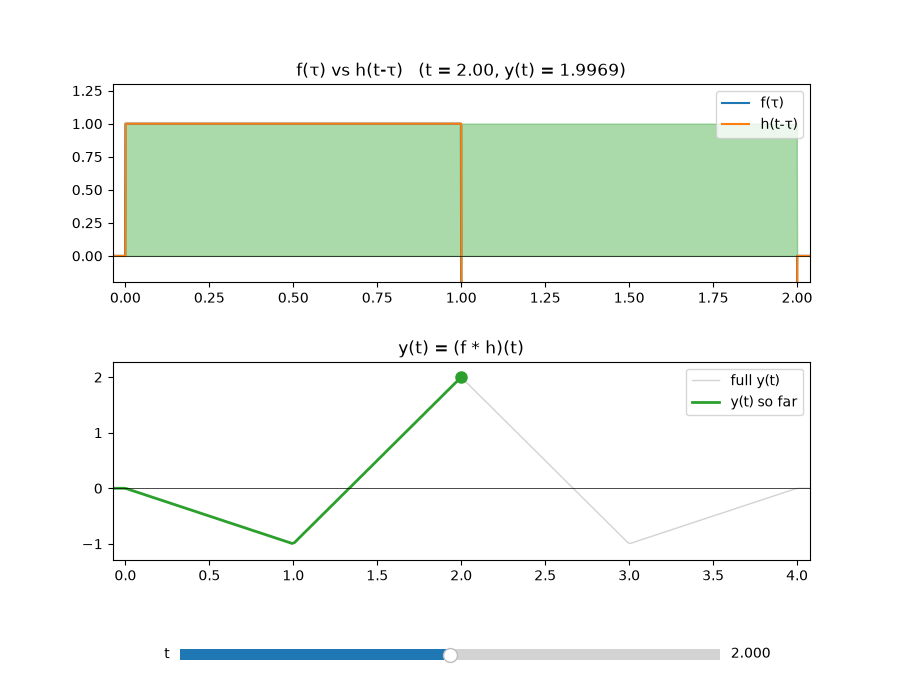

{'f': <function __main__.f(x)>,
 'h': <function __main__.h(x)>,
 'fa': np.float64(-0.038401870093504785),
 'fb': np.float64(2.0385018750937536),
 'ha': np.float64(-0.038401870093504785),
 'hb': np.float64(2.0385018750937536),
 'tau': array([-0.03840187, -0.03736342, -0.03632497, ...,  2.03642497,
         2.03746342,  2.03850188], shape=(2001,)),
 'f_vals': array([0., 0., 0., ..., 0., 0., 0.], shape=(2001,)),
 'dx': np.float64(0.0010384518725936292),
 't_lo': np.float64(-0.07680374018700957),
 't_hi': np.float64(4.077003750187507)}

In [ ]:
%matplotlib widget

def f(x):
    return np.where((x >= 0) & (x <= 1), 3.0, np.where((x>=1) & (x<=2), -3.0 , 0.0))

def h(x):
    return np.where((x >= 0) & (x <= 1), -3.0, np.where((x>=1) & (x<=2), 3.0 , 0.0))

visualize(f, h)